# HR Analytics & Employee Attrition — Phase A: EDA

Dataset: IBM HR Analytics Attrition Dataset (Kaggle) — single clean CSV, ~1,470 rows, 35 columns.
File name from Kaggle: `WA_Fn-UseC_-HR-Employee-Attrition.csv`

Steps:
1. Load and check nulls
2. Overall attrition rate
3. Attrition by Department, JobRole, OverTime, MaritalStatus, Age band, YearsAtCompany
4. Chi-squared test: Attrition vs OverTime
5. Correlation heatmap
6. Identify top attrition drivers

In [15]:
# Basic imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [16]:
# Load the dataset
hr_data = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(hr_data.shape)
hr_data.head()


(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1. Check nulls and data types

In [17]:
# Check for missing values
print(hr_data.isnull().sum().sum(), "total missing values")

# Check data types
hr_data.dtypes.value_counts()

0 total missing values


int64    26
str       9
Name: count, dtype: int64

In [18]:
# Quick look at the target column
hr_data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

## 2. Overall attrition rate

In [19]:
# Convert Attrition to 1/0 for easier math later
hr_data['Attrition_Flag'] = hr_data['Attrition'].map({'Yes': 1, 'No': 0})

overall_rate = hr_data['Attrition_Flag'].mean() * 100
print("Overall attrition rate:", round(overall_rate, 2), "%")

Overall attrition rate: 16.12 %


## 3. Attrition rate by category

In [20]:
# Attrition by Department
dept_attrition = hr_data.groupby('Department')['Attrition_Flag'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False)
print(dept_attrition.round(2))

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition_Flag, dtype: float64


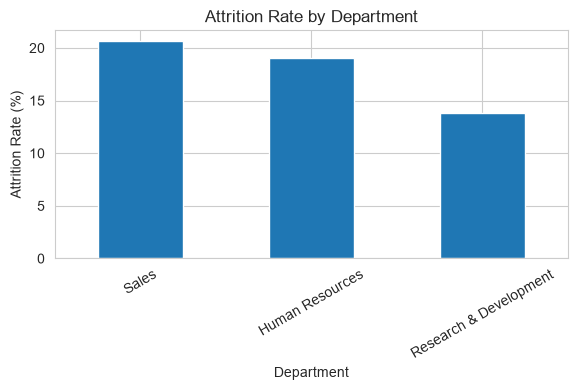

In [23]:
# Chart it
dept_attrition.plot(kind='bar', figsize=(6, 4))
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Department')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [24]:
# Attrition by Job Role
role_attrition = hr_data.groupby('JobRole')['Attrition_Flag'].mean() * 100
role_attrition = role_attrition.sort_values(ascending=False)
print(role_attrition.round(2))

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition_Flag, dtype: float64


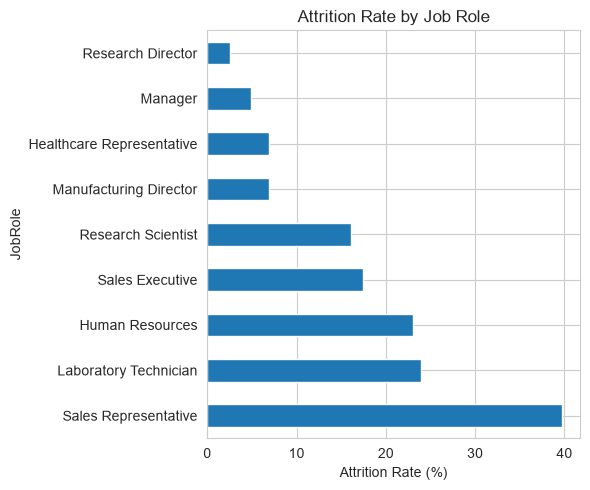

In [26]:
#Chart it 
role_attrition.plot(kind='barh', figsize=(6, 5))
plt.xlabel('Attrition Rate (%)')
plt.title('Attrition Rate by Job Role')
plt.tight_layout()
plt.show()

In [28]:
# Attrition by OverTime (Yes/No) — a variable worth checking closely
overtime_attrition = hr_data.groupby('OverTime')['Attrition_Flag'].mean() * 100
print(overtime_attrition.round(2))

OverTime
No     10.44
Yes    30.53
Name: Attrition_Flag, dtype: float64


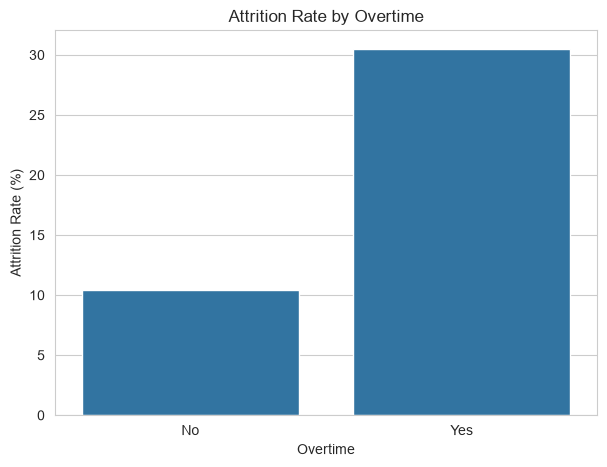

In [29]:
#Chart it 
overtime_attrition = hr_data.groupby('OverTime')['Attrition_Flag'].mean() * 100

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(
    x=overtime_attrition.index,
    y=overtime_attrition.values
)

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')

plt.show()

In [30]:
# Attrition by Marital Status
marital_attrition = hr_data.groupby('MaritalStatus')['Attrition_Flag'].mean() * 100
print(marital_attrition.round(2))

MaritalStatus
Divorced    10.09
Married     12.48
Single      25.53
Name: Attrition_Flag, dtype: float64


In [34]:
# Create Age bands, then check attrition by band
bins = [18, 25, 35, 45, 60]
labels = ['18-25', '26-35', '36-45', '46-60']
hr_data['AgeBand'] = pd.cut(hr_data['Age'], bins=bins, labels=labels)

age_attrition = hr_data.groupby('AgeBand', observed=True)['Attrition_Flag'].mean() * 100
print(age_attrition.round(2))

AgeBand
18-25    34.78
26-35    19.14
36-45     9.19
46-60    12.45
Name: Attrition_Flag, dtype: float64


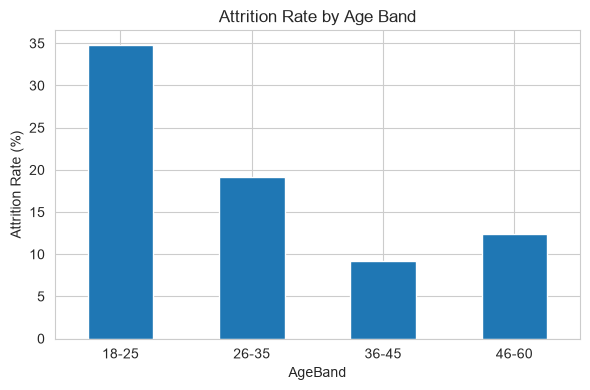

In [36]:
age_attrition.plot(kind='bar', figsize=(6, 4))
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Age Band')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
# Attrition by tenure — YearsAtCompany, grouped into bands
tenure_bins = [0, 2, 5, 10, 40]
tenure_labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs']
hr_data['TenureBand'] = pd.cut(hr_data['YearsAtCompany'], bins=tenure_bins, labels=tenure_labels)

tenure_attrition = hr_data.groupby('TenureBand', observed=True)['Attrition_Flag'].mean() * 100
print(tenure_attrition.round(2))

TenureBand
0-2 yrs     28.86
3-5 yrs     13.82
6-10 yrs    12.28
10+ yrs      8.13
Name: Attrition_Flag, dtype: float64


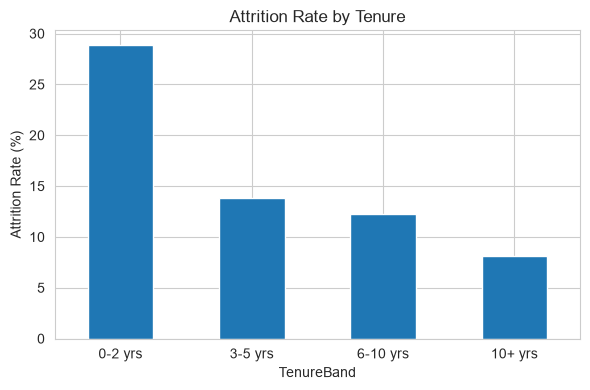

In [40]:
tenure_attrition.plot(kind='bar', figsize=(6, 4))
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Tenure')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Chi-squared test: Attrition vs OverTime

Both variables are categorical (Yes/No), so a chi-squared test of independence is the right test 

In [42]:
# Step 1: build a contingency table (cross-tab of counts)
contingency_table = pd.crosstab(hr_data['OverTime'], hr_data['Attrition'])
print(contingency_table)

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


In [44]:
# Step 2: run the chi-squared test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared statistic:", round(chi2_stat, 3))
print("p-value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: significant relationship — OverTime is linked to Attrition")
else:
    print("Result: no significant relationship found")

Chi-squared statistic: 87.564
p-value: 0.0
Result: significant relationship — OverTime is linked to Attrition


## 5. Correlation heatmap — numeric variables vs Attrition

In [45]:
# Pick numeric columns likely to matter, plus the Attrition flag
numeric_cols = ['Attrition_Flag', 'Age', 'MonthlyIncome', 'JobSatisfaction',
                 'WorkLifeBalance', 'YearsAtCompany', 'DistanceFromHome',
                 'TotalWorkingYears', 'NumCompaniesWorked', 'JobInvolvement']

corr_matrix = hr_data[numeric_cols].corr()
corr_matrix

,Attrition_Flag,Age,MonthlyIncome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,DistanceFromHome,TotalWorkingYears,NumCompaniesWorked,JobInvolvement
Attrition_Flag,1.000000,-0.159205,-0.159840,-0.103481,-0.063939,-0.134392,0.077924,-0.171063,0.043494,-0.130016
Age,-0.159205,1.000000,0.497855,-0.004892,-0.021490,0.311309,-0.001686,0.680381,0.299635,0.029820
MonthlyIncome,-0.159840,0.497855,1.000000,-0.007157,0.030683,0.514285,-0.017014,0.772893,0.149515,-0.015271
JobSatisfaction,-0.103481,-0.004892,-0.007157,1.000000,-0.019459,-0.003803,-0.003669,-0.020185,-0.055699,-0.021476
WorkLifeBalance,-0.063939,-0.021490,0.030683,-0.019459,1.000000,0.012089,-0.026556,0.001008,-0.008366,-0.014617
YearsAtCompany,-0.134392,0.311309,0.514285,-0.003803,0.012089,1.000000,0.009508,0.628133,-0.118421,-0.021355
DistanceFromHome,0.077924,-0.001686,-0.017014,-0.003669,-0.026556,0.009508,1.000000,0.004628,-0.029251,0.008783
TotalWorkingYears,-0.171063,0.680381,0.772893,-0.020185,0.001008,0.628133,0.004628,1.000000,0.237639,-0.005533
NumCompaniesWorked,0.043494,0.299635,0.149515,-0.055699,-0.008366,-0.118421,-0.029251,0.237639,1.000000,0.015012
JobInvolvement,-0.130016,0.029820,-0.015271,-0.021476,-0.014617,-0.021355,0.008783,-0.005533,0.015012,1.000000


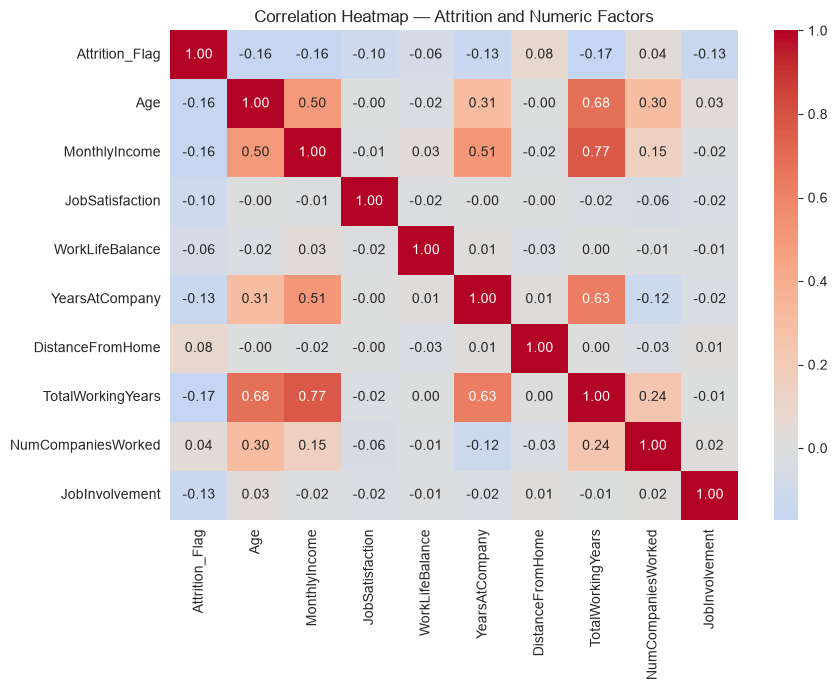

In [46]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Attrition and Numeric Factors')
plt.tight_layout()
plt.show()

In [47]:
# Show just the correlations with Attrition_Flag, sorted
attrition_corr = corr_matrix['Attrition_Flag'].sort_values(ascending=False)
print(attrition_corr)

Attrition_Flag        1.000000
DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
WorkLifeBalance      -0.063939
JobSatisfaction      -0.103481
JobInvolvement       -0.130016
YearsAtCompany       -0.134392
Age                  -0.159205
MonthlyIncome        -0.159840
TotalWorkingYears    -0.171063
Name: Attrition_Flag, dtype: float64


### Conclusion: 
The correlation analysis shows that no single numerical variable has a strong linear relationship with attrition. Age, monthly income, and total working years show weak negative correlations with attrition. 